<a href="https://colab.research.google.com/github/AEE099/Hospital-Imaging-Data-analisys/blob/main/Hospital_Data_analisys.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Demand and productivity Analisys - Imaging department (2024)

**By:** Alonzo Encarnacion

**Objective:** Analyze the volume of studies made during the year 2024 with the purpose of identify seasonality, participation by modality and propose optimizations in the patient care flow.

--

## 📊 Planned workflow

1. **Phase 1:** Data Cleaning, Preparation, and Transformation (Unpivoting).

2. **Phase 2:** General Descriptive Analysis (Percentage of Participation).

3. **Phase 3:** Analysis of Temporal Trends and Seasonality.

4. **Phase 4:** Segmentation by Operational Complexity.

##Phase 1: Data Cleaning, Preparation, and Transformation (Unpivoting).

*Objective: Eliminate control rows (subtotals) and pivot the table to work in long format (Tidy Data).*



In [10]:
import pandas as pd
import numpy as np

#1. Data
df_data= pd.read_excel("DATA 2024.xlsx" , skiprows=3)
#2.Clean empty
df_clean=df_data.dropna(subset=["ESTUDIO"]).copy()

#3.Clean names , strings
df_clean["ESTUDIO"]=df_clean["ESTUDIO"].str.replace("**","", regex=False).str.strip()
df_clean["ESTUDIO"]=df_clean["ESTUDIO"].str.replace(" ","_", regex=False).str.strip()

#4. Separe  operative data from total and subtotal to avoid
df_totales= df_clean[df_clean["ESTUDIO"].isin(["SUB-TOTAL", "TOTAL_GENERAL"])].copy()
df_estudios=df_clean[~df_clean["ESTUDIO"].isin(["SUB-TOTAL" , "TOTAL_GENERAL" ,])].copy()

#5. long format, (melt)

meses= ["ENERO" , "FEBRERO" , "MARZO" , "ABRIL" , "MAYO" , "JUNIO" , "JULIO" , "AGOSTO" , "SEPTIEMB" , "OCTUBRE" , "NOVIEMB" , "DICIEMB"]

df_long=pd.melt(
    df_estudios,
    id_vars=["ESTUDIO"],
    value_vars=meses,
    var_name="MES",
    value_name="CANTIDAD"
)
#CONVERT AMOUNT IN INT
df_long["CANTIDAD"] = df_long["CANTIDAD"].astype(int)

print("Data transformed! Format ready to by analyzed")
print(df_long.head(20))


Data transformed! Format ready to by analyzed
                      ESTUDIO      MES  CANTIDAD
0                          RX    ENERO      6481
1              DENSITOMETRIAS    ENERO       482
2                 TOMOGRAFIAS    ENERO      3290
3                 SONOGRAFIAS    ENERO      9692
4                 MAMOGRAFIAS    ENERO       749
5                 RESONANCIAS    ENERO      1711
6                    BIOPSIAS    ENERO       161
7   RIV/DRENAJE/TOMODIRIGIDAS    ENERO        28
8           ANGIOGRAFIAS(RIV)    ENERO         2
9         M.NUCLEAR._ESTUDIOS    ENERO       239
10        M.N._PROCEDIMIENTOS    ENERO        39
11                         RX  FEBRERO      5930
12             DENSITOMETRIAS  FEBRERO       521
13                TOMOGRAFIAS  FEBRERO      3306
14                SONOGRAFIAS  FEBRERO      8965
15                MAMOGRAFIAS  FEBRERO       780
16                RESONANCIAS  FEBRERO      1733
17                   BIOPSIAS  FEBRERO       125
18  RIV/DRENAJE/TOMODIR

## 2. **Phase 2:** General Descriptive Analysis (Percentage of Participation).

*Objective: To calculate the total volume and market share of each imaging modality.*



In [11]:
#Calculate total by catergory
total_estudios = df_long["CANTIDAD"].sum()
participacion= df_long.groupby("ESTUDIO")["CANTIDAD"].sum().reset_index()

#Calculate percentage
participacion["% PARTICIPACION"]= (participacion["CANTIDAD"] / total_estudios) * 100
participacion= participacion.sort_values(by="CANTIDAD", ascending=False)

print(f"Total volume operative analized: {total_estudios:,} estudios.")
participacion.style.format({"CANTIDAD":"{:,}","% PARTICIPACION" : "{:.2F}%"})


Total volume operative analized: 272,059 estudios.


,ESTUDIO,CANTIDAD,% PARTICIPACION
9,SONOGRAFIAS,"113,707",41.79%
8,RX,"79,787",29.33%
10,TOMOGRAFIAS,"38,271",14.07%
6,RESONANCIAS,"20,670",7.60%
5,MAMOGRAFIAS,"8,608",3.16%
2,DENSITOMETRIAS,"5,611",2.06%
4,M.NUCLEAR._ESTUDIOS,"2,815",1.03%
1,BIOPSIAS,"2,009",0.74%
3,M.N._PROCEDIMIENTOS,303,0.11%
7,RIV/DRENAJE/TOMODIRIGIDAS,265,0.10%


##3. **Phase 3:** Analysis of Temporal Trends and Seasonality.

*Objective: To evaluate monthly demand patterns in order to identify peak months and the behavior of key services.*



In [12]:
#Group by month to check year curve
tendencia_mensual = df_long.groupby("MES") ["CANTIDAD"].sum().reindex(meses)

#Pivot to anal multivariable or heatmaps

matriz_estudio= df_long.pivot_table(index="ESTUDIO", columns="MES",values="CANTIDAD" , aggfunc="sum")[meses]
matriz_estudio


MES,ENERO,FEBRERO,MARZO,ABRIL,MAYO,JUNIO,JULIO,AGOSTO,SEPTIEMB,OCTUBRE,NOVIEMB,DICIEMB
ESTUDIO,,,,,,,,,,,,
ANGIOGRAFIAS(RIV),2,3,1,1,2,0,1,0,0,2,0,1
BIOPSIAS,161,125,118,146,162,175,241,229,170,171,173,138
DENSITOMETRIAS,482,521,472,504,493,434,488,491,422,485,462,357
M.N._PROCEDIMIENTOS,39,34,30,39,54,32,0,25,0,26,0,24
M.NUCLEAR._ESTUDIOS,239,274,254,284,269,197,107,249,212,291,237,202
MAMOGRAFIAS,749,780,755,671,787,711,812,682,605,811,698,547
RESONANCIAS,1711,1733,1683,1786,1736,1701,1827,1767,1732,1889,1565,1540
RIV/DRENAJE/TOMODIRIGIDAS,28,12,25,21,22,29,29,19,7,29,24,20
RX,6481,5930,6257,7225,7153,6773,6950,6497,6485,7572,6334,6130


##4. **Phase 4:** Segmentation by Operational Complexity.

*Objective: To classify the different types of studies into three main categories based on resource demand, equipment occupancy time, and required medical intervention. This allows us to understand the department's true operational workload beyond simple net volume.*


### Segmentation Criteria:
1. **High Turnover / Low Complexity:** Rapid, high-volume studies that represent the massive daily flow (X-rays, Ultrasounds, Bone Densitometry, Mammograms).
2. **High Complexity / Longer Time:** Studies that require advanced equipment, longer acquisition time per patient, and more controlled scheduling (CT Scans, MRIs, Nuclear Medicine).
3. **Interventional Procedures:** Procedures that involve needles, special supplies, or real-time guidance (Biopsies, IV Angiography, Drainage).




In [13]:
# 1. Define the reality-based mapping function of the department

def clasificar_complejidad(estudio):
  alta_rotacion = ["RX" ,"SONOGRAFIAS" , "DENSITOMETRIAS" , "MAMOGRAFIAS"]
  alta_complejidad = ["TOMOGRAFIAS" , "RESONANCIAS" ,"M.NUCLEAR._ESTUDIOS"]
  intervencionismo= ["BIOPSIAS" , "RIV/DRENAJE/TOMODIRIGIDAS", "ANGIOGRAFIAS(RIV)" , "M.N._PROCEDIMIENTOS" ]

  if estudio in alta_rotacion:
    return "Alta Rotacion / Baja Complejidad"
  elif estudio in alta_complejidad:
    return "Alta Complejidad / Mayor tiempo"
  elif estudio in intervencionismo:
    return "Procedimiento Intervencionismo"
  else:
    return "No clasificado"


#2.Apply segmentation to the transformed DataFrame (df_long)

df_long["COMPLEJIDAD"] = df_long ["ESTUDIO"]. apply(clasificar_complejidad)

# 3. Add the data to see the macro view of the workload

resumen_complejidad = df_long.groupby("COMPLEJIDAD")["CANTIDAD"].sum().reset_index()

# 4. Calculate the percentage of impact of each segment
total_operativo= resumen_complejidad["CANTIDAD"].sum()
resumen_complejidad["% PARTICIPACION"] = (resumen_complejidad["CANTIDAD"] / total_operativo) * 100

# 5. Sort the results for better readability

resumen_complejidad= resumen_complejidad.sort_values(by="CANTIDAD", ascending=False)

#Show results

print(f"RESUMEN DE CARGA OPERATIVA POR COMPLEJIDAD")
resumen_complejidad.style.format({
    "CANTIDAD": "{:,}",
    "%PARTICIPACION": "{:.2f}%"
})



RESUMEN DE CARGA OPERATIVA POR COMPLEJIDAD


,COMPLEJIDAD,CANTIDAD,% PARTICIPACION
1,Alta Rotacion / Baja Complejidad,"207,713",76.348513
0,Alta Complejidad / Mayor tiempo,"61,756",22.699488
2,Procedimiento Intervencionismo,"2,590",0.951999


In [14]:
breakdown_complejidad = df_long.groupby(["COMPLEJIDAD" , "ESTUDIO"])["CANTIDAD"].sum().reset_index()
breakdown_complejidad = breakdown_complejidad.sort_values(by=["COMPLEJIDAD" , "CANTIDAD"], ascending=[True , False])
print("\n DESGLOSE DETALLADO POR MODALIDAD")
breakdown_complejidad.style.format({"CANTIDAD": "{:,}"})


 DESGLOSE DETALLADO POR MODALIDAD


,COMPLEJIDAD,ESTUDIO,CANTIDAD
2,Alta Complejidad / Mayor tiempo,TOMOGRAFIAS,"38,271"
1,Alta Complejidad / Mayor tiempo,RESONANCIAS,"20,670"
0,Alta Complejidad / Mayor tiempo,M.NUCLEAR._ESTUDIOS,"2,815"
6,Alta Rotacion / Baja Complejidad,SONOGRAFIAS,"113,707"
5,Alta Rotacion / Baja Complejidad,RX,"79,787"
4,Alta Rotacion / Baja Complejidad,MAMOGRAFIAS,"8,608"
3,Alta Rotacion / Baja Complejidad,DENSITOMETRIAS,"5,611"
8,Procedimiento Intervencionismo,BIOPSIAS,"2,009"
9,Procedimiento Intervencionismo,M.N._PROCEDIMIENTOS,303
10,Procedimiento Intervencionismo,RIV/DRENAJE/TOMODIRIGIDAS,265


## Phase 5: Data Visualization and Insight Extraction


*Objective: To translate numerical tables into clear graphs that facilitate operational decision-making and the identification of demand patterns.*


/tmp/ipykernel_2642/269736770.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


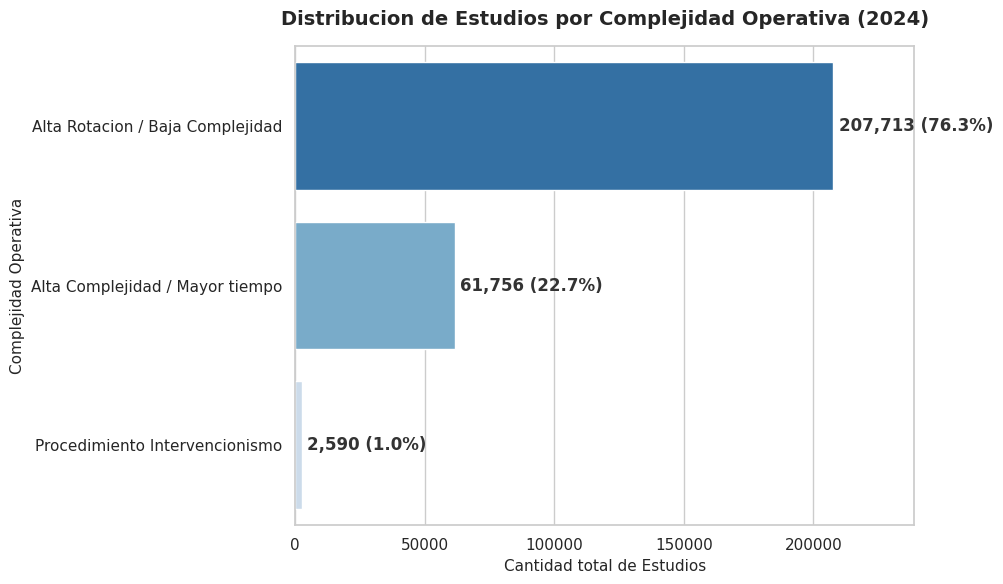

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

#Global aesthetic configuracion
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "sans-serif"

#1.Prepare the chart data
resumen_grafico1= df_long.groupby("COMPLEJIDAD") ["CANTIDAD"].sum().reset_index()
resumen_grafico1= resumen_grafico1.sort_values(by="CANTIDAD", ascending=False)

#2.Initialize the figure
fig, ax = plt.subplots(figsize=(10,6
                              ))

#3. horizontal bar chart
sns.barplot(
    data=resumen_grafico1,
    x="CANTIDAD",
    y="COMPLEJIDAD",
    palette="Blues_r",
    ax=ax
)

#4.Data label
total_estudios = resumen_grafico1["CANTIDAD"].sum()
for idx, fila in enumerate(resumen_grafico1.itertuples()):
  porcentaje= (fila.CANTIDAD / total_estudios) * 100
  #TEXT: "QUANTITY"(PERCENTAGE %)
  texto= f"{fila.CANTIDAD:,} ({porcentaje:.1f}%)"
  ax.text(fila.CANTIDAD + 2000, idx, texto, va="center", fontweight="bold", color="#333333")

#5.  Customize titles and axes
ax.set_title("Distribucion de Estudios por Complejidad Operativa (2024)", fontsize=14 , pad=15 ,fontweight="bold")
ax.set_xlabel("Cantidad total de Estudios", fontsize=11)
ax.set_ylabel("Complejidad Operativa", fontsize=11)
ax.set_xlim(0, resumen_grafico1["CANTIDAD"].max() * 1.15) #Extra Space between tags

plt.tight_layout()


plt.show()




/tmp/ipykernel_2642/3387849203.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_2642/3387849203.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45 , ha="right")


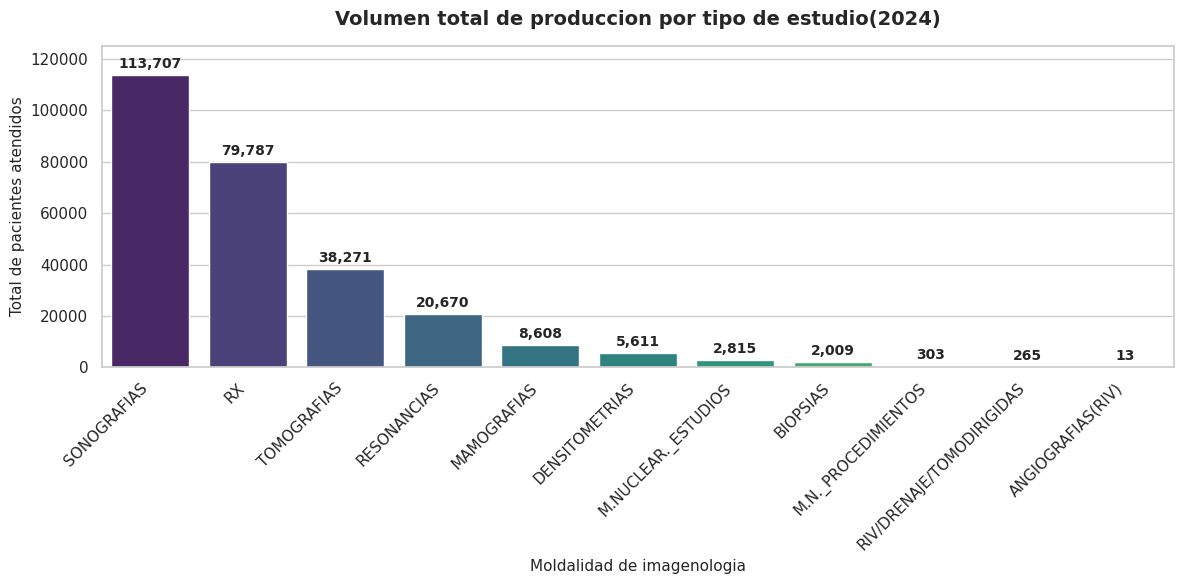

In [16]:
#Chart 2 - Top Most Requested Modalities
#1.Group by stu
top_estudios = df_long.groupby("ESTUDIO")["CANTIDAD"].sum().reset_index()
top_estudios = top_estudios.sort_values(by= "CANTIDAD",ascending= False)

#2.Create the fig

fig, ax= plt.subplots(figsize=(12,6))

#3. vertical bar chart
sns.barplot(
    data=top_estudios,
    x="ESTUDIO",
    y="CANTIDAD",
    palette="viridis",
    ax=ax
)

#4. Move named from axis X
ax.set_xticklabels(ax.get_xticklabels(), rotation=45 , ha="right")

#5. Add labels above the bars
for p in ax.patches:
  ax.annotate(
      f"{int(p.get_height()):,}",
      (p.get_x() + p.get_width() / 2. , p.get_height()),
      ha="center" , va="center",
      xytext=(0,8),
      textcoords="offset points",
      fontsize= 10, fontweight="bold"
  )

ax.set_title("Volumen total de produccion por tipo de estudio(2024)" , fontsize=14, pad=15, fontweight="bold")
ax.set_xlabel("Moldalidad de imagenologia" , fontsize=11)
ax.set_ylabel("Total de pacientes atendidos" , fontsize=11)
ax.set_ylim(0, top_estudios["CANTIDAD"].max() * 1.1)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2642/1550988918.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(orden_meses)


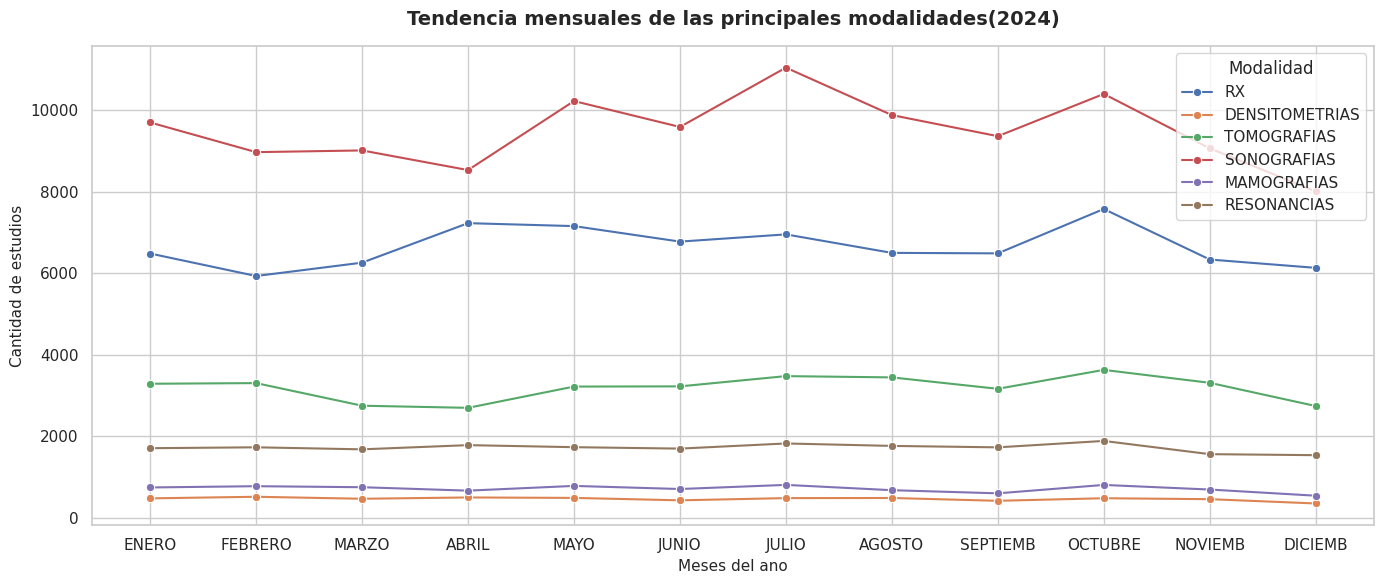

In [17]:
#Chart 3 - Temporal Behavior and Seasonality

#1. Define the strict order of the months on the X-axis

orden_meses= ["ENERO" , "FEBRERO" , "MARZO" , "ABRIL" , "MAYO" , "JUNIO" , "JULIO" , "AGOSTO" , "SEPTIEMB" , "OCTUBRE" , "NOVIEMB" , "DICIEMB"]

# 2. Filter only the 4 main modalities to avoid cluttering the line graph
principales_modalidades= ["SONOGRAFIAS" , "RX" , "TOMOGRAFIAS" , "RESONANCIAS" , "MAMOGRAFIAS" , "DENSITOMETRIAS"]
df_filtrado_tiempo= df_long[df_long["ESTUDIO"].isin(principales_modalidades)].copy()

#3.Create the fig

fig, ax= plt.subplots(figsize=(14,6))

#4.   chart
sns.lineplot(
    data=df_filtrado_tiempo,
    x="MES",
    y="CANTIDAD",
    hue="ESTUDIO",
    marker="o",
    ax=ax
)

 #5. Format and month sorting settings

ax.set_xticklabels(orden_meses)
ax.set_title("Tendencia mensuales de las principales modalidades(2024)", fontsize=14 , pad=15 , fontweight="bold")
ax.set_xlabel("Meses del ano" , fontsize=11)
ax.set_ylabel("Cantidad de estudios" , fontsize=11)
ax.legend(title="Modalidad", frameon=True)

plt.tight_layout()
plt.show()


## End-to-End Data Pipeline Automation

*Objective: To encapsulate the logic of cleaning, transformation, classification, and visualization in an automated pipeline that processes new reports from the Imaging Department with a single click.*


In [18]:
# Celda 1: Importas tu propio módulo personalizado
from procesador_imagenes import ejecutar_pipeline_imagenes

# Celda 2: Defines la ruta del nuevo archivo y corres el pipeline
data_nueva = 'DATA 2024.xlsx'

# Ejecución automática
df_resultados = ejecutar_pipeline_imagenes(ruta_archivo=data_nueva, carpeta_salida='reporte_2024')

📁 Carpeta 'reporte_2024' creada para los resultados.
⏳ Iniciando procesamiento automático...
✅ Datos transformados y segmentados.


/content/procesador_imagenes.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resumen_c1, x='CANTIDAD', y='COMPLEJIDAD', palette='Blues_r', ax=ax1)
/content/procesador_imagenes.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_e, x='ESTUDIO', y='CANTIDAD', palette='viridis', ax=ax2)
/content/procesador_imagenes.py:79: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
/content/procesador_imagenes.py:89: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLoca


🎉 ¡Pipeline ejecutado con éxito!
📦 Gráficos guardados en: 'reporte_2024/'
--------------------------------------------------
📈 Total Estudios Procesados: 272,059
🗓️ Promedio de Producción Mensual: 22,671 estudios/mes
--------------------------------------------------


##Trabajando los ML


In [19]:
archivos={
    2022:["DATA 2022.xlsx"],
    2023:["DATA 2023.xlsx"],
    2024:["DATA 2024.xlsx"],
}

dataframes=[]
meses=['ENERO', 'FEBRERO', 'MARZO', 'ABRIL', 'MAYO', 'JUNIO',
         'JULIO', 'AGOSTO', 'SEPTIEMB', 'OCTUBRE', 'NOVIEMB', 'DICIEMB']

for anio, achivo in archivos.items():
  #Saltamos las primeras 3 lines con el titulo
  df=pd.read_excel(achivo[0], skiprows=3)

  #Eliminamos columnas vacia y total que no sea usado para el entrenamiento

  df=df.dropna(subset=["ESTUDIO"])
  if "TOTAL" in df.columns:
    df= df.drop(columns=["TOTAL"])

    #Transformamos a formato largo (melt)

    df_melted=df.melt(id_vars=["ESTUDIO"], value_vars=meses,
                      var_name="MES", value_name="Volumen")

    df_melted["Ano"]= anio
    dataframes.append(df_melted)

#Unir el df

df_final= pd.concat(dataframes, ignore_index=True)

#Convertimos a numero drop na

df_final["Volumen"]=pd.to_numeric(df_final["Volumen"], errors="coerce")

df_final=df_final.dropna()

print(df_final.head())


          ESTUDIO    MES  Volumen   Ano
0              RX  ENERO   5286.0  2022
1  DENSITOMETRIAS  ENERO    230.0  2022
2     TOMOGRAFIAS  ENERO   3103.0  2022
3     SONOGRAFIAS  ENERO   5083.0  2022
4     MAMOGRAFIAS  ENERO    374.0  2022


In [20]:
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor , GradientBoostingRegressor
from sklearn.svm import SVR


#Separar valores

X=df_final[["ESTUDIO" ,"MES", "Ano"]
           ]
y=df_final["Volumen"]


#Dividir datos de entrenmiento prueba(80%/20%)

X_train, X_test, y_train ,  y_test= train_test_split(X, y, test_size=0.2 , random_state=42)

#Preprocesamiento : one hot para estudio y mes

preprocessor= ColumnTransformer(
    transformers= [
        ("cat", OneHotEncoder(handle_unknown="ignore"), ["ESTUDIO", "MES"])
    ], remainder="passthrough") # Corrected: changed "passthrought" to "passthrough"



#Modelos

modelos={ "Rreresion Lineal": LinearRegression(),
         "Ridge (Lineal Regularizado)": Ridge(),
          "Random Forest": RandomForestRegressor(),
          "Grandient Boosting": GradientBoostingRegressor(),
          "SVR (vector soporte)": SVR()
}


#Evaluar modelos

resultados_cv={}
for nombre, modelo in modelos.items():

  pipeline= Pipeline(steps=[("preprocesador", preprocessor), ("modelo", modelo)])
  scores= cross_val_score(pipeline, X_train, y_train, cv=5 , scoring="r2")
  resultados_cv [nombre]= scores.mean()
#Usamos R2 como metrica de comparacion

#Mostrar resutados en orden

print("Rendimiento promedio (R2) en validación cruzada:")
for nombre, score in sorted (resultados_cv.items(), key=lambda x: x[1], reverse=True):
  print(f"{nombre}: {score:.4f}")

Rendimiento promedio (R2) en validación cruzada:
Grandient Boosting: 0.9901
Random Forest: 0.9888
Rreresion Lineal: 0.9871
Ridge (Lineal Regularizado): 0.9854
SVR (vector soporte): -0.3212


In [21]:
from sklearn.model_selection import GridSearchCV

#1.optimizar randim forest

pipeline_rf=Pipeline(steps=[("preprocesador", preprocessor),
                            ("modelo", RandomForestRegressor(random_state=42))])

param_grid_rf= {
    "modelo__n_estimators": [50,75,100,125,150,200],
    "modelo__max_depth": [None, 5, 10, 15, 20, 25,30],
    "modelo__min_samples_split": [2, 4,6,8,10]
}
grid_rf= GridSearchCV(pipeline_rf, param_grid_rf, cv=5, scoring="r2", n_jobs=-1)
grid_rf.fit(X_train, y_train)


#2.Opti grandient boosting

pipeline_gb=Pipeline(steps=[("preprocesador", preprocessor),
                            ("modelo", GradientBoostingRegressor(random_state=42))])
param_grid_gb={
    "modelo__n_estimators": [50,75,100,125,150,200],
    "modelo__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "modelo__max_depth": [3,4,5,6,7,8]
}
grid_gb= GridSearchCV(pipeline_gb, param_grid_gb, cv=5, scoring="r2", n_jobs=-1)
grid_gb.fit(X_train, y_train)

print(f"Mejor R2 Random Forest: {grid_rf.best_score_:.4f} con {grid_rf.best_params_}")
print(f"Mejor R2 Gradient Boosting: {grid_gb.best_score_:.4f} con {grid_gb.best_params_}")

# Seleccionamos el ganador absoluto
mejor_modelo = grid_rf if grid_rf.best_score_ > grid_gb.best_score_ else grid_gb
print(f"\nModelo seleccionado: {mejor_modelo.best_estimator_.named_steps['modelo'].__class__.__name__}")




Mejor R2 Random Forest: 0.9896 con {'modelo__max_depth': 15, 'modelo__min_samples_split': 6, 'modelo__n_estimators': 50}
Mejor R2 Gradient Boosting: 0.9916 con {'modelo__learning_rate': 0.2, 'modelo__max_depth': 3, 'modelo__n_estimators': 150}

Modelo seleccionado: GradientBoostingRegressor


In [22]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#predicciones con el conjunto de pruea
y_pred= mejor_modelo.predict(X_test)

#Calculamos las metricas

r2= r2_score(y_test, y_pred)
mse= mean_squared_error(y_test, y_pred)
mae= mean_absolute_error(y_test, y_pred)
rmse= np.sqrt(mse)

print("=== Evaluación Final en el Set de Prueba ===")

print(f"R2 Score: {r2:.4f} (Qué tan bien explica la varianza, más cerca de 1 es mejor)")

print(f"Mean Absolute Error (MAE): {mae:.2f} (Error promedio absoluto en volumen de estudios)")

print(f"Root Mean Squared Error (RMSE): {rmse:.2f} (Penaliza errores grandes, idealmente bajo)")

=== Evaluación Final en el Set de Prueba ===
R2 Score: 0.9931 (Qué tan bien explica la varianza, más cerca de 1 es mejor)
Mean Absolute Error (MAE): 309.85 (Error promedio absoluto en volumen de estudios)
Root Mean Squared Error (RMSE): 601.24 (Penaliza errores grandes, idealmente bajo)


In [23]:
# Crear un DataFrame con los datos que queremos predecir
datos_futuros = pd.DataFrame({
    'ESTUDIO': ['SONOGRAFIAS', 'TOMOGRAFIAS', 'RX'],
    'MES': ['ENERO', 'FEBRERO', 'MARZO'],
    'Ano': [2025, 2025, 2025]
})

# Hacer la predicción directamente con el pipeline optimizado
predicciones_2025 = mejor_modelo.predict(datos_futuros)

# Mostrar los resultados
datos_futuros['Volumen_Proyectado'] = predicciones_2025.round(0) # Redondeamos a números enteros
print("\n=== Proyecciones de Volumen ===")
print(datos_futuros)


=== Proyecciones de Volumen ===
       ESTUDIO      MES   Ano  Volumen_Proyectado
0  SONOGRAFIAS    ENERO  2025              9407.0
1  TOMOGRAFIAS  FEBRERO  2025              3073.0
2           RX    MARZO  2025              6339.0


In [24]:
# 1. División estricta por tiempo (Evita la fuga de datos)
train_data = df_final[df_final['Ano'] <= 2023]
test_data = df_final[df_final['Ano'] == 2024]

X_train_time = train_data[['ESTUDIO', 'MES', 'Ano']]
y_train_time = train_data['Volumen']

X_test_time = test_data[['ESTUDIO', 'MES', 'Ano']]
y_test_time = test_data['Volumen']

# Entrenamos el mejor modelo (ej. Random Forest) con la data cronológica
modelo_auditoria = Pipeline(steps=[
    ('preprocesador', preprocessor),
    ('modelo', GradientBoostingRegressor(random_state=42, learning_rate=0.2, max_depth=3, n_estimators=150))
    # Usa tus mejores hiperparámetros aquí
])

modelo_auditoria.fit(X_train_time, y_train_time)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocesador',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['ESTUDIO', 'MES'])])),
                ('modelo',
                 GradientBoostingRegressor(learning_rate=0.2, n_estimators=150,
                                           random_state=42))])

In [25]:
# Predicciones en entrenamiento (lo que ya vio)
y_pred_train = modelo_auditoria.predict(X_train_time)
# Predicciones en prueba (el año 2024 que nunca vio)
y_pred_test = modelo_auditoria.predict(X_test_time)

print("=== Auditoría de Sobreajuste (Train vs Test) ===")
print(f"R2 en Entrenamiento (2022-2023): {r2_score(y_train_time, y_pred_train):.4f}")
print(f"R2 en Prueba (2024): {r2_score(y_test_time, y_pred_test):.4f}")

print(f"\nMAE en Entrenamiento: {mean_absolute_error(y_train_time, y_pred_train):.2f}")
print(f"MAE en Prueba (2024): {mean_absolute_error(y_test_time, y_pred_test):.2f}")

=== Auditoría de Sobreajuste (Train vs Test) ===
R2 en Entrenamiento (2022-2023): 0.9986
R2 en Prueba (2024): 0.9904

MAE en Entrenamiento: 161.63
MAE en Prueba (2024): 424.42


In [26]:
# Extraer los nombres de las columnas después del One-Hot Encoding
nombres_cat = modelo_auditoria.named_steps['preprocesador'].transformers_[0][1].get_feature_names_out(['ESTUDIO', 'MES'])
nombres_columnas = list(nombres_cat) + ['Ano']

# Extraer la importancia de las características del Random Forest
importancias = modelo_auditoria.named_steps['modelo'].feature_importances_

# Crear un DataFrame para visualizarlo fácilmente
df_importancias = pd.DataFrame({
    'Variable': nombres_columnas,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

print("\n=== Importancia de las Variables ===")
print(df_importancias.head(10))


=== Importancia de las Variables ===
                 Variable  Importancia
10      ESTUDIO_SUB-TOTAL     0.463967
12  ESTUDIO_TOTAL GENERAL     0.405542
9     ESTUDIO_SONOGRAFIAS     0.073845
8              ESTUDIO_RX     0.035673
11    ESTUDIO_TOMOGRAFIAS     0.005486
25                    Ano     0.004091
16              MES_ENERO     0.002566
15            MES_DICIEMB     0.001492
20              MES_MARZO     0.001237
6     ESTUDIO_RESONANCIAS     0.001005


##Posible fuga encontrada debidop a dos columnas, subtotal y total general, addressing issue

In [27]:
import pandas as pd

archivos = {
    2022: 'DATA 2022.xlsx',
    2023: 'DATA 2023.xlsx',
    2024: 'DATA 2024.xlsx'
}

dataframes = []
meses = ['ENERO', 'FEBRERO', 'MARZO', 'ABRIL', 'MAYO', 'JUNIO',
         'JULIO', 'AGOSTO', 'SEPTIEMB', 'OCTUBRE', 'NOVIEMB', 'DICIEMB']

for anio, archivo in archivos.items():
    # Saltamos el encabezado general
    df=pd.read_excel(archivo, skiprows=3)

    # 1. Eliminamos las filas completamente vacías
    df = df.dropna(subset=['ESTUDIO'])

    # 2. ELIMINACIÓN DE LA FUGA EN FILAS:
    # Filtramos para quedarnos solo con las filas que NO (~) contienen la palabra "TOTAL"
    df = df[~df['ESTUDIO'].astype(str).str.contains('TOTAL', case=False, na=False)]

    # 3. Eliminamos la columna TOTAL si existe (fuga horizontal)
    if 'TOTAL' in df.columns:
        df = df.drop(columns=['TOTAL'])

    # Transformamos al formato largo para el modelo
    df_melted = df.melt(id_vars=['ESTUDIO'], value_vars=meses,
                        var_name='MES', value_name='Volumen')
    df_melted['Ano'] = anio
    dataframes.append(df_melted)

df_final = pd.concat(dataframes, ignore_index=True)
df_final['Volumen'] = pd.to_numeric(df_final['Volumen'], errors='coerce')
df_final = df_final.dropna()

# Verificamos rápidamente que los totales ya no existan en la lista de estudios únicos
print("Estudios que el modelo va a procesar:")
print(df_final['ESTUDIO'].unique())

Estudios que el modelo va a procesar:
['RX' 'DENSITOMETRIAS' 'TOMOGRAFIAS' 'SONOGRAFIAS' 'MAMOGRAFIAS'
 'RESONANCIAS' 'BIOPSIAS' 'RIV/DRENAJE/TOMODIRIGIDAS' 'ANGIOGRAFIAS(RIV)'
 'M.NUCLEAR. ESTUDIOS **' 'M.N. PROCEDIMIENTOS**']


In [28]:
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor , GradientBoostingRegressor
from sklearn.svm import SVR


#Separar valores

X=df_final[["ESTUDIO" ,"MES", "Ano"]
           ]
y=df_final["Volumen"]


#Dividir datos de entrenmiento prueba(80%/20%)

X_train, X_test, y_train ,  y_test= train_test_split(X, y, test_size=0.2 , random_state=42)

#Preprocesamiento : one hot para estudio y mes

preprocessor= ColumnTransformer(
    transformers= [
        ("cat", OneHotEncoder(handle_unknown="ignore"), ["ESTUDIO", "MES"])
    ], remainder="passthrough") # Corrected: changed "passthrought" to "passthrough"



#Modelos

modelos={ "Rreresion Lineal": LinearRegression(),
         "Ridge (Lineal Regularizado)": Ridge(),
          "Random Forest": RandomForestRegressor(),
          "Grandient Boosting": GradientBoostingRegressor(),
          "SVR (vector soporte)": SVR()
}


#Evaluar modelos

resultados_cv={}
for nombre, modelo in modelos.items():

  pipeline= Pipeline(steps=[("preprocesador", preprocessor), ("modelo", modelo)])
  scores= cross_val_score(pipeline, X_train, y_train, cv=5 , scoring="r2")
  resultados_cv [nombre]= scores.mean()
#Usamos R2 como metrica de comparacion

#Mostrar resutados en orden

print("Rendimiento promedio (R2) en validación cruzada:")
for nombre, score in sorted (resultados_cv.items(), key=lambda x: x[1], reverse=True):
  print(f"{nombre}: {score:.4f}")

Rendimiento promedio (R2) en validación cruzada:
Grandient Boosting: 0.9925
Random Forest: 0.9908
Rreresion Lineal: 0.9875
Ridge (Lineal Regularizado): 0.9855
SVR (vector soporte): -0.2581


In [29]:
from sklearn.model_selection import GridSearchCV

#1.optimizar randim forest

pipeline_rf=Pipeline(steps=[("preprocesador", preprocessor),
                            ("modelo", RandomForestRegressor(random_state=42))])

param_grid_rf= {
    "modelo__n_estimators": [50,75,100,125,150,200],
    "modelo__max_depth": [None, 5, 10, 15, 20, 25,30],
    "modelo__min_samples_split": [2, 4,6,8,10]
}
grid_rf= GridSearchCV(pipeline_rf, param_grid_rf, cv=5, scoring="r2", n_jobs=-1)
grid_rf.fit(X_train, y_train)


#2.Opti grandient boosting

pipeline_gb=Pipeline(steps=[("preprocesador", preprocessor),
                            ("modelo", GradientBoostingRegressor(random_state=42))])
param_grid_gb={
    "modelo__n_estimators": [50,75,100,125,150,200],
    "modelo__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "modelo__max_depth": [3,4,5,6,7,8]
}
grid_gb= GridSearchCV(pipeline_gb, param_grid_gb, cv=5, scoring="r2", n_jobs=-1)
grid_gb.fit(X_train, y_train)

print(f"Mejor R2 Random Forest: {grid_rf.best_score_:.4f} con {grid_rf.best_params_}")
print(f"Mejor R2 Gradient Boosting: {grid_gb.best_score_:.4f} con {grid_gb.best_params_}")

# Seleccionamos el ganador absoluto
mejor_modelo = grid_rf if grid_rf.best_score_ > grid_gb.best_score_ else grid_gb
print(f"\nModelo seleccionado: {mejor_modelo.best_estimator_.named_steps['modelo'].__class__.__name__}")




Mejor R2 Random Forest: 0.9909 con {'modelo__max_depth': 15, 'modelo__min_samples_split': 4, 'modelo__n_estimators': 100}
Mejor R2 Gradient Boosting: 0.9930 con {'modelo__learning_rate': 0.1, 'modelo__max_depth': 3, 'modelo__n_estimators': 200}

Modelo seleccionado: GradientBoostingRegressor


In [30]:
# 2. División Cronológica estricta (Evitar memorización)
train_data = df_final[df_final['Ano'] <= 2023] # El modelo estudia el pasado
test_data = df_final[df_final['Ano'] == 2024]  # El modelo se examina en el futuro

X_train = train_data[['ESTUDIO', 'MES', 'Ano']]
y_train = train_data['Volumen']

X_test = test_data[['ESTUDIO', 'MES', 'Ano']]
y_test = test_data['Volumen']

# 3. Preprocesamiento y Entrenamiento
preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), ['ESTUDIO', 'MES'])],
    remainder='passthrough'
)

# Usamos RandomForest como ejemplo, ajusta los hiperparámetros según tu grid search anterior
modelo_auditoria = Pipeline(steps=[
    ('preprocesador', preprocessor),
    ('modelo',GradientBoostingRegressor(random_state=42, learning_rate=0.2, max_depth=3, n_estimators=150))
])

modelo_auditoria.fit(X_train, y_train)

# 4. Evaluación de Memorización (Train vs Test)
y_pred_train = modelo_auditoria.predict(X_train)
y_pred_test = modelo_auditoria.predict(X_test)

print("=== Auditoría de Sobreajuste y Fuga de Datos ===")
print(f"R2 en Entrenamiento (2022-2023): {r2_score(y_train, y_pred_train):.4f}")
print(f"R2 en Prueba (2024): {r2_score(y_test, y_pred_test):.4f}")

print(f"\nMAE en Entrenamiento: {mean_absolute_error(y_train, y_pred_train):.2f}")
print(f"MAE en Prueba (2024): {mean_absolute_error(y_test, y_pred_test):.2f}")

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
print(f"RMSE en Prueba (2024): {rmse_test:.2f}")

=== Auditoría de Sobreajuste y Fuga de Datos ===
R2 en Entrenamiento (2022-2023): 0.9991
R2 en Prueba (2024): 0.9885

MAE en Entrenamiento: 58.43
MAE en Prueba (2024): 177.10
RMSE en Prueba (2024): 326.60


In [31]:
# Extraer los nombres de las columnas después del One-Hot Encoding
nombres_cat = modelo_auditoria.named_steps['preprocesador'].transformers_[0][1].get_feature_names_out(['ESTUDIO', 'MES'])
nombres_columnas = list(nombres_cat) + ['Ano']

# Extraer la importancia de las características del Random Forest
importancias = modelo_auditoria.named_steps['modelo'].feature_importances_

# Crear un DataFrame para visualizarlo fácilmente
df_importancias = pd.DataFrame({
    'Variable': nombres_columnas,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

print("\n=== Importancia de las Variables ===")
print(df_importancias.head(10))


=== Importancia de las Variables ===
                             Variable  Importancia
9                 ESTUDIO_SONOGRAFIAS     0.566825
8                          ESTUDIO_RX     0.324909
10                ESTUDIO_TOMOGRAFIAS     0.069039
6                 ESTUDIO_RESONANCIAS     0.015408
23                                Ano     0.005298
14                          MES_ENERO     0.004293
7   ESTUDIO_RIV/DRENAJE/TOMODIRIGIDAS     0.001917
3       ESTUDIO_M.N. PROCEDIMIENTOS**     0.001870
13                        MES_DICIEMB     0.001838
0           ESTUDIO_ANGIOGRAFIAS(RIV)     0.001703


In [32]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#predicciones con el conjunto de pruea
y_pred= mejor_modelo.predict(X_test)

#Calculamos las metricas

r2= r2_score(y_test, y_pred)
mse= mean_squared_error(y_test, y_pred)
mae= mean_absolute_error(y_test, y_pred)
rmse= np.sqrt(mse)

print("=== Evaluación Final en el Set de Prueba ===")

print(f"R2 Score: {r2:.4f} (Qué tan bien explica la varianza, más cerca de 1 es mejor)")

print(f"Mean Absolute Error (MAE): {mae:.2f} (Error promedio absoluto en volumen de estudios)")

print(f"Root Mean Squared Error (RMSE): {rmse:.2f} (Penaliza errores grandes, idealmente bajo)")

=== Evaluación Final en el Set de Prueba ===
R2 Score: 0.9977 (Qué tan bien explica la varianza, más cerca de 1 es mejor)
Mean Absolute Error (MAE): 78.85 (Error promedio absoluto en volumen de estudios)
Root Mean Squared Error (RMSE): 144.66 (Penaliza errores grandes, idealmente bajo)


In [33]:
# Crear un DataFrame con los datos que queremos predecir
datos_futuros = pd.DataFrame({
    'ESTUDIO': ['SONOGRAFIAS', 'TOMOGRAFIAS', 'RX'],
    'MES': ['ENERO', 'FEBRERO', 'MARZO'],
    'Ano': [2025, 2025, 2025]
})

# Hacer la predicción directamente con el pipeline optimizado
predicciones_2025 = mejor_modelo.predict(datos_futuros)

# Mostrar los resultados
datos_futuros['Volumen_Proyectado'] = predicciones_2025.round(0) # Redondeamos a números enteros
print("\n=== Proyecciones de Volumen ===")
print(datos_futuros)


=== Proyecciones de Volumen ===
       ESTUDIO      MES   Ano  Volumen_Proyectado
0  SONOGRAFIAS    ENERO  2025              9226.0
1  TOMOGRAFIAS  FEBRERO  2025              3050.0
2           RX    MARZO  2025              6540.0
